In [1]:
# 1. IMPORTS & SETUP
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
import warnings

from IPython.display import display
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier




# Notebook Configurations
%matplotlib inline
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')
print("Environment initialized.")

Environment initialized.


In [2]:
# 2. DATA LOADING & INITIAL PRUNING
print("Loading Oracle's Elixir dataset...")
file_path = "2024_LoL_esports_match_data_from_OraclesElixir1.csv" # Ensure this matches your file name!

raw_df = pd.read_csv(file_path, sep=';', low_memory=False)

# Drop columns that provide zero mathematical value
useless_columns = ['url', 'league', 'year', 'split', 'date', 'patch', 'playerid', 'teamid']
df = raw_df.drop(columns=[col for col in useless_columns if col in raw_df.columns])

print(f"Working Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

Loading Oracle's Elixir dataset...
Working Dataset Shape: 12276 rows and 115 columns


In [3]:
df.head()

,gameid,datacompleteness,playoffs,game,participantid,side,position,playername,teamname,champion,...,opp_csat15,golddiffat15,xpdiffat15,csdiffat15,killsat15,assistsat15,deathsat15,opp_killsat15,opp_assistsat15,opp_deathsat15
0,10660-10660_game_1,partial,0,1,1,Blue,top,Zika,LNG Esports,Aatrox,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10660-10660_game_1,partial,0,1,2,Blue,jng,Weiwei,LNG Esports,Maokai,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10660-10660_game_1,partial,0,1,3,Blue,mid,Scout,LNG Esports,Orianna,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10660-10660_game_1,partial,0,1,4,Blue,bot,GALA,LNG Esports,Kalista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10660-10660_game_1,partial,0,1,5,Blue,sup,Mark,LNG Esports,Senna,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12276 entries, 0 to 12275
Columns: 115 entries, gameid to opp_deathsat15
dtypes: float64(84), int64(19), object(12)
memory usage: 10.8+ MB


In [5]:
df.describe()

,playoffs,game,participantid,gamelength,result,kills,deaths,assists,teamkills,teamdeaths,...,opp_csat15,golddiffat15,xpdiffat15,csdiffat15,killsat15,assistsat15,deathsat15,opp_killsat15,opp_assistsat15,opp_deathsat15
count,12276.000000,12276.000000,12276.000000,12276.000000,12276.00000,12276.000000,12276.000000,12276.000000,12276.000000,12276.000000,...,10032.000000,10032.000000,10032.000000,10032.000000,10032.000000,10032.000000,10032.000000,10032.000000,10032.000000,10032.000000
mean,0.025415,1.370479,29.583333,1932.027370,0.50000,4.560606,4.571033,10.678560,13.681818,13.713099,...,174.008174,0.000000,0.000000,0.000000,1.258174,2.132177,1.263357,1.258174,2.132177,1.263357
std,0.157390,0.627351,57.652816,336.192335,0.50002,5.549481,5.303874,12.803308,7.089714,7.082772,...,161.299420,1328.808798,1024.943004,28.236035,1.822918,3.101974,1.765999,1.822918,3.101974,1.765999
min,0.000000,1.000000,1.000000,1271.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.000000,-9921.000000,-7485.000000,-138.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,3.750000,1689.000000,0.00000,1.000000,2.000000,3.000000,8.000000,8.000000,...,95.000000,-579.250000,-510.000000,-13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,6.500000,1886.000000,0.50000,3.000000,3.000000,7.000000,13.000000,13.000000,...,128.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,0.000000,2.000000,9.250000,2141.000000,1.00000,6.000000,5.000000,12.000000,19.000000,19.000000,...,147.000000,579.250000,510.000000,13.000000,2.000000,3.000000,2.000000,2.000000,3.000000,2.000000
max,1.000000,5.000000,200.000000,3226.000000,1.00000,39.000000,39.000000,98.000000,39.000000,39.000000,...,634.000000,9921.000000,7485.000000,138.000000,16.000000,32.000000,16.000000,16.000000,32.000000,16.000000


In [6]:
df.isnull().sum()

gameid                 0
datacompleteness       0
playoffs               0
game                   0
participantid          0
                    ... 
assistsat15         2244
deathsat15          2244
opp_killsat15       2244
opp_assistsat15     2244
opp_deathsat15      2244
Length: 115, dtype: int64

In [7]:
# 3. TYPE A PREPROCESSING: 15-Minute Game State (No Leakage Risk)
print("Engineering 15-Minute Game State...")

# Step 1: Keep only team rows to avoid duplicating player-level data
teams = df[df['position'] == 'team'].copy()

# Step 2: Clean and filter Gold Difference at 15 mins (Drop missing rows)
teams['golddiffat15'] = pd.to_numeric(teams['golddiffat15'], errors='coerce')
teams = teams.dropna(subset=['golddiffat15'])

# Step 3: Calculate Plate Difference (Our plates minus Opponent's plates)
teams['platediff'] = pd.to_numeric(teams['turretplates'], errors='coerce') - \
                     pd.to_numeric(teams['opp_turretplates'], errors='coerce')

# Step 4: Calculate KDA at 15 minutes (Added +1 to deaths to prevent division by zero)
kills = pd.to_numeric(teams['killsat15'], errors='coerce')
assists = pd.to_numeric(teams['assistsat15'], errors='coerce')
deaths = pd.to_numeric(teams['deathsat15'], errors='coerce')
teams['kda_15'] = (kills + assists) / (deaths + 1)

# Step 5: Encode side (Blue = 1, Red = 0)
teams['side_encoded'] = teams['side'].map({'Blue': 1, 'Red': 0})

# Step 6: Add safe 15-minute "First" objectives (Newly added for better insights)
teams['firstblood']  = pd.to_numeric(teams['firstblood'], errors='coerce').fillna(0)
teams['firstdragon'] = pd.to_numeric(teams['firstdragon'], errors='coerce').fillna(0)
teams['firstherald'] = pd.to_numeric(teams['firstherald'], errors='coerce').fillna(0)
teams['firsttower']  = pd.to_numeric(teams['firsttower'], errors='coerce').fillna(0)

# Output the final confirmation shape
print(f"Engineered Phase 1 features for {teams.shape[0]} team instances.")

Engineering 15-Minute Game State...
Engineered Phase 1 features for 1672 team instances.


 Ingénierie des Caractéristiques Macro (Feature Engineering)
Pour capturer le véritable état du jeu à 15 minutes, nous devons traduire les statistiques brutes des joueurs en métriques globales pour chaque équipe. 

Nouvelles Caractéristiques (Features) :
 Différence d'Or et de Plaques (Gold & Plate Diff) : Indique le contrôle de la carte et la domination économique.
 Différence d'XP : Calculée à partir des niveaux des joueurs pour mesurer la domination individuelle en ligne (Lane dominance).
 KDA & Objectifs : Représente le succès lors des combats d'équipe (Teamfights) et le contrôle des objectifs neutres.

In [8]:
# 4. THE TRAIN/TEST BOUNDARY & DRAFT ADVANTAGE
print("Splitting data to protect against Data Leakage...")

train_teams, test_teams = train_test_split(teams, test_size=0.2, random_state=42)
train_game_ids = train_teams['gameid'].unique()

players_df = df[df['position'] != 'team'].copy()
train_players = players_df[players_df['gameid'].isin(train_game_ids)]

train_champ_win_rates = train_players.groupby('champion')['result'].mean().to_dict()

def engineer_draft(team_subset, player_subset, win_rates):
    p_sub = player_subset[player_subset['gameid'].isin(team_subset['gameid'])].copy()
    p_sub['champ_winrate'] = p_sub['champion'].map(win_rates).fillna(0.5)
    
    draft_feats = p_sub.pivot(index=['gameid', 'side'], columns='position', values='champ_winrate').reset_index()
    draft_feats['team_draft_strength'] = draft_feats[['top', 'jng', 'mid', 'bot', 'sup']].mean(axis=1)
    
    opp_draft = draft_feats[['gameid', 'side', 'team_draft_strength']].copy()
    opp_draft['side'] = opp_draft['side'].map({'Blue': 'Red', 'Red': 'Blue'})
    opp_draft.rename(columns={'team_draft_strength': 'opp_draft_strength'}, inplace=True)
    
    final_draft = pd.merge(draft_feats, opp_draft, on=['gameid', 'side'])
    final_draft['draft_adv'] = final_draft['team_draft_strength'] - final_draft['opp_draft_strength']
    
    return pd.merge(team_subset, final_draft[['gameid', 'side', 'draft_adv']], on=['gameid', 'side'])

train_master = engineer_draft(train_teams, players_df, train_champ_win_rates)
test_master = engineer_draft(test_teams, players_df, train_champ_win_rates)
print("Target Encoding Complete! No Data Leakage detected.")

Splitting data to protect against Data Leakage...
Target Encoding Complete! No Data Leakage detected.


 Délimitation Train/Test & Encodage Cible (Target Encoding)
Étape Critique : Prévention de la Fuite de Données (Data Leakage)

Pour évaluer la force de la composition d'une équipe (Draft Advantage), nous calculons les taux de victoire historiques des champions sélectionnés. Cependant, calculer cela sur l'ensemble du jeu de données provoquerait une fuite de données sévère. Pour garantir l'intégrité mathématique :
1.  Séparation Stricte : Nous divisons les données en ensembles d'entraînement (Train) et de test (Test) *avant* de calculer les taux de victoire.
2.  Encodage Isolé : Les taux de victoire des champions sont calculés STRICTEMENT sur l'ensemble `Train`. L'ensemble `Test` reste totalement invisible. Les champions inconnus dans l'ensemble de test reçoivent un taux de victoire neutre par défaut (50%).

Running EDA Plots...


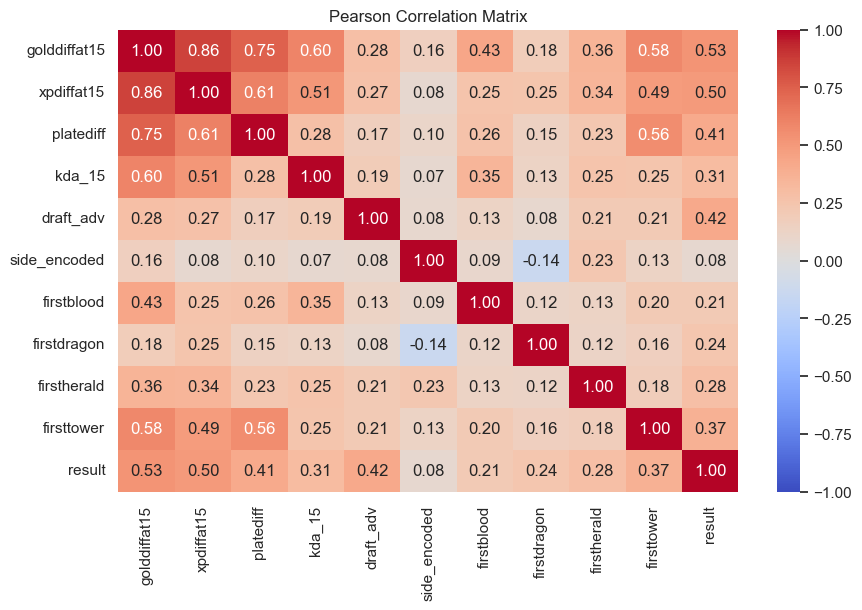

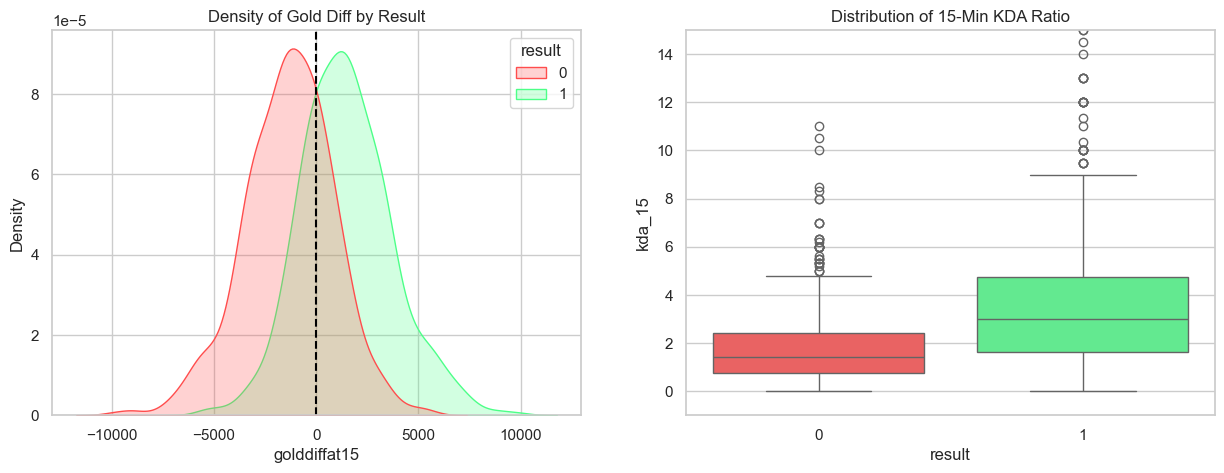

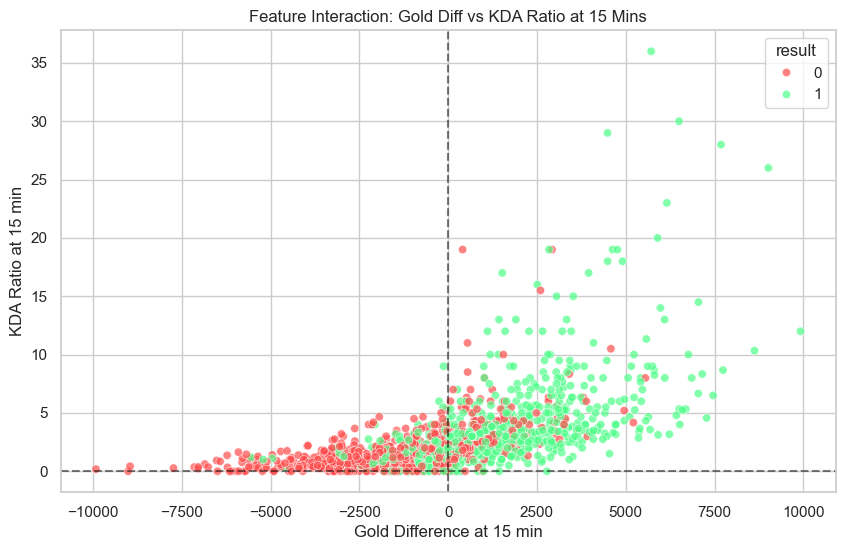

--- Comeback Analysis ---
Total games with Gold Disadvantage at 15m: 665
Games won after 15m disadvantage (Comebacks): 176
Pure Comeback Rate: 26.47%



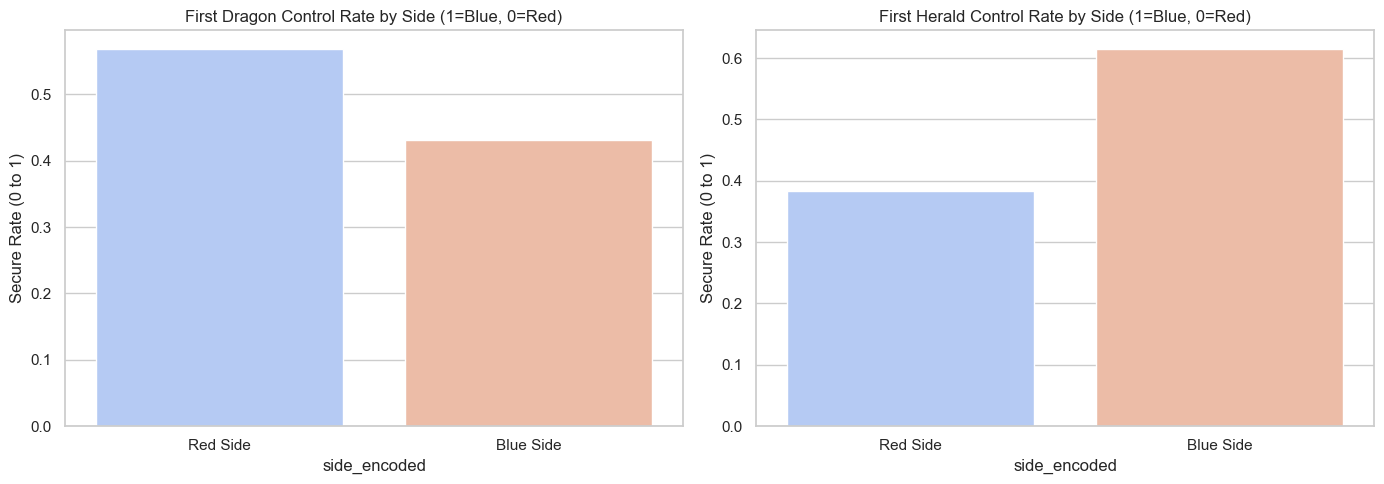

--- Outlier & Throw Analysis ---
Number of massive throws (Lead > 4000g at 15m but Lost): 4


,teamname,golddiffat15,gamelength
404,RED Canids,4580.0,2068
428,Ground Zero Gaming,4955.0,2322
568,Sengoku Gaming,5551.0,1880
814,One More Esports,5214.0,1981


--------------------------------------------------


In [9]:
# 5. EXPLORATORY DATA ANALYSIS (EDA)
print("Running EDA Plots...")

features = ['golddiffat15', 'xpdiffat15', 'platediff', 'kda_15', 'draft_adv', 'side_encoded', 'firstblood', 'firstdragon', 'firstherald', 'firsttower']
for col in features + ['result']:
    train_master[col] = pd.to_numeric(train_master[col], errors='coerce')

# =====================================================================
# Plot 1: The Heatmap
# =====================================================================
plt.figure(figsize=(10, 6))
sns.heatmap(train_master[features + ['result']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Pearson Correlation Matrix')
plt.show()

# =====================================================================
# Plot 2: Density and Boxplots
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.kdeplot(data=train_master, x='golddiffat15', hue='result', fill=True, palette=['#ff4d4d', '#4dff88'], ax=axes[0])
axes[0].set_title('Density of Gold Diff by Result')
axes[0].axvline(0, color='black', linestyle='--')

sns.boxplot(data=train_master, x='result', y='kda_15', palette=['#ff4d4d', '#4dff88'], ax=axes[1])
axes[1].set_title('Distribution of 15-Min KDA Ratio')
axes[1].set_ylim(-1, 15)
plt.show()


# Make sure all required columns are numeric in train_master
advanced_eda_features = features + ['result', 'firstdragon', 'firstherald']
for col in advanced_eda_features:
    if col in train_master.columns:
        train_master[col] = pd.to_numeric(train_master[col], errors='coerce')

# =====================================================================
# PLOT 3: Feature Interaction (Gold Diff vs KDA Ratio colored by Result)
# =====================================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=train_master, 
    x='golddiffat15', 
    y='kda_15', 
    hue='result', 
    palette=['#ff4d4d', '#4dff88'], 
    alpha=0.7
)
plt.title('Feature Interaction: Gold Diff vs KDA Ratio at 15 Mins')
plt.xlabel('Gold Difference at 15 min')
plt.ylabel('KDA Ratio at 15 min')
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

# =====================================================================
# PLOT 4: The Comeback Analysis (Quantifying 15-Min Disadvantages)
# =====================================================================
# Find matches where a team was losing in gold at 15m but ended up winning
gold_disadvantage = train_master[train_master['golddiffat15'] < 0]
total_disadvantages = len(gold_disadvantage)
successful_comebacks = len(gold_disadvantage[gold_disadvantage['result'] == 1])

if total_disadvantages > 0:
    comeback_rate = (successful_comebacks / total_disadvantages) * 100
    print(f"--- Comeback Analysis ---")
    print(f"Total games with Gold Disadvantage at 15m: {total_disadvantages}")
    print(f"Games won after 15m disadvantage (Comebacks): {successful_comebacks}")
    print(f"Pure Comeback Rate: {comeback_rate:.2f}%\n")

# =====================================================================
# PLOT 5: Map Bias Analysis (Side Impact on First Objectives)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# First Dragon by Side
sns.barplot(
    data=train_master, 
    x='side_encoded', 
    y='firstdragon', 
    ax=axes[0], 
    palette='coolwarm', 
    errorbar=None
)
axes[0].set_title('First Dragon Control Rate by Side (1=Blue, 0=Red)')
axes[0].set_ylabel('Secure Rate (0 to 1)')
axes[0].set_xticklabels(['Red Side', 'Blue Side'])

# First Herald by Side
sns.barplot(
    data=train_master, 
    x='side_encoded', 
    y='firstherald', 
    ax=axes[1], 
    palette='coolwarm', 
    errorbar=None
)
axes[1].set_title('First Herald Control Rate by Side (1=Blue, 0=Red)')
axes[1].set_ylabel('Secure Rate (0 to 1)')
axes[1].set_xticklabels(['Red Side', 'Blue Side'])

plt.tight_layout()
plt.show()

# =====================================================================
# PLOT 6: Analyzing Extreme Outliers (Massive Throws)
# =====================================================================
# Extreme lead means winning by more than 4000 gold at 15 mins but losing the game
massive_throws = train_master[(train_master['golddiffat15'] > 4000) & (train_master['result'] == 0)]
print(f"--- Outlier & Throw Analysis ---")
print(f"Number of massive throws (Lead > 4000g at 15m but Lost): {len(massive_throws)}")
if len(massive_throws) > 0:
    display(massive_throws[['teamname', 'golddiffat15', 'gamelength']])
print("-" * 50)

In [10]:
# Ensure clean features and target split
X_train = train_master[features].fillna(0)
y_train = train_master['result']
X_test = test_master[features].fillna(0)
y_test = test_master['result']

print("Building and training Advanced Machine Learning Pipelines...")

# --- DEFINE ALL MODEL PIPELINES WITH ROBUSTSCALER ---
pipelines = {
    "Logistic Regression": Pipeline([
        ('scaler', RobustScaler()),
        ('classifier', LogisticRegression(random_state=42))
    ]),
    
    "Random Forest": Pipeline([
        ('scaler', RobustScaler()),
        ('classifier', RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42))
    ]),
    
    "Gradient Boosting": Pipeline([
        ('scaler', RobustScaler()),
        ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42))
    ]),
    
    "AdaBoost": Pipeline([
        ('scaler', RobustScaler()),
        ('classifier', AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42))
    ]),
    
    "XGBoost": Pipeline([
        ('scaler', RobustScaler()),
        # Using use_label_encoder=False to follow modern XGBoost standards
        ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42, eval_metric='logloss'))
    ])
}

# --- AUTOMATED LOOP FOR TRAINING AND EVALUATION ---
for name, pipe in pipelines.items():
    # 1. Fit the entire pipeline (Scales and Trains automatically)
    pipe.fit(X_train, y_train)
    
    # 2. Predict on raw test data
    y_pred = pipe.predict(X_test)
    
    # 3. Print Results
    print(f"\n=== {name} Performance ===")
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Test F1-Score: {f1_score(y_test, y_pred):.4f}")

Building and training Advanced Machine Learning Pipelines...

=== Logistic Regression Performance ===
Test Accuracy: 0.7731
Test F1-Score: 0.7738

=== Random Forest Performance ===
Test Accuracy: 0.7791
Test F1-Score: 0.7798

=== Gradient Boosting Performance ===
Test Accuracy: 0.7433
Test F1-Score: 0.7378

=== AdaBoost Performance ===
Test Accuracy: 0.7522
Test F1-Score: 0.7477

=== XGBoost Performance ===
Test Accuracy: 0.7672
Test F1-Score: 0.7651


 Construction des Pipelines de Base et Évaluation Initiale

Avant de procéder à l'optimisation poussée (Hyperparameter Tuning), nous devons établir des performances de référence (Baselines) avec des paramètres standards. 

Pour garantir une intégrité mathématique totale et éviter toute fuite de données (Data Leakage) lors des futures étapes de validation, nous encapsulons notre processus dans des `Pipelines` scikit-learn. 

Composition de chaque Pipeline :
1. RobustScaler : Appliqué en premier, il standardise les caractéristiques (Features) tout en étant résistant aux valeurs aberrantes (outliers) très fréquentes dans les métriques de jeu (ex: différences d'or extrêmes).
2. Le Classifieur : L'algorithme de Machine Learning (Forêt Aléatoire, XGBoost, Régression Logistique, etc.).

La boucle ci-dessous entraîne automatiquement chaque pipeline et affiche ses métriques brutes sur l'ensemble de test.

Generating Final Evaluation Reports and Confusion Matrices...

Detailed Classification Report for Logistic Regression
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       169
           1       0.76      0.78      0.77       166

    accuracy                           0.77       335
   macro avg       0.77      0.77      0.77       335
weighted avg       0.77      0.77      0.77       335



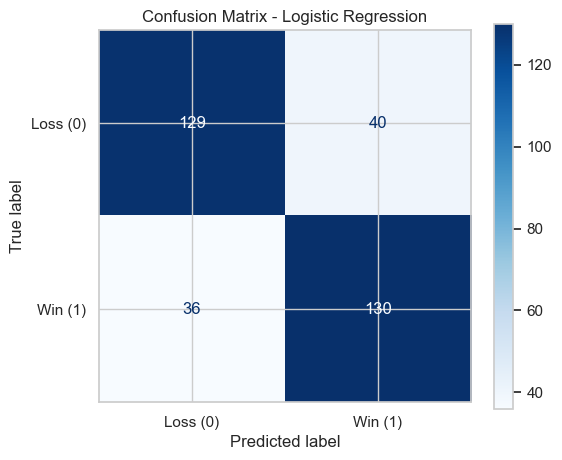


Detailed Classification Report for Random Forest
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       169
           1       0.77      0.79      0.78       166

    accuracy                           0.78       335
   macro avg       0.78      0.78      0.78       335
weighted avg       0.78      0.78      0.78       335



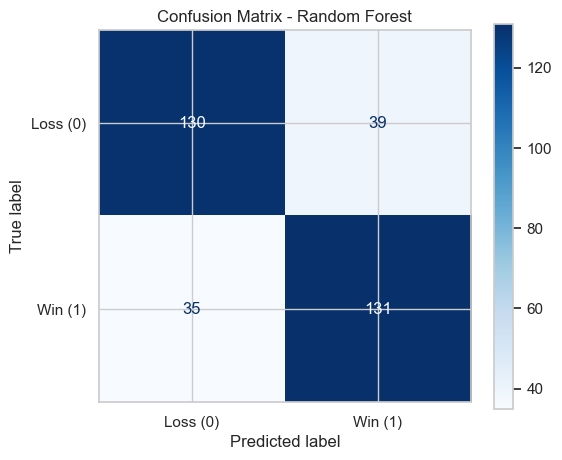


Detailed Classification Report for XGBoost
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       169
           1       0.77      0.77      0.77       166

    accuracy                           0.77       335
   macro avg       0.77      0.77      0.77       335
weighted avg       0.77      0.77      0.77       335



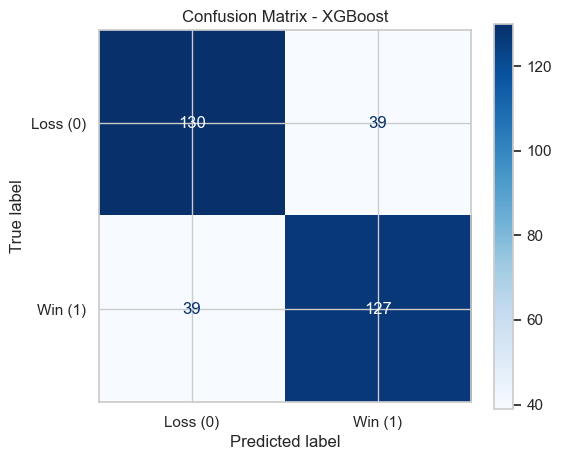

In [11]:
# Using the 3 best models we found: Logistic Regression, XGBoost and Random Forest
best_models = {
    "Logistic Regression": pipelines["Logistic Regression"],
    "Random Forest": pipelines["Random Forest"],
    "XGBoost": pipelines["XGBoost"]
}

print("Generating Final Evaluation Reports and Confusion Matrices...")

for name, model in best_models.items():
    # Predict on the test set
    y_pred = model.predict(X_test)
    
    print("\n" + "="*50)
    print(f"Detailed Classification Report for {name}")
    print("="*50)
    # Prints Precision, Recall, and F1-Score for both classes (0 and 1)
    print(classification_report(y_test, y_pred))
    
    # Generate and plot the Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Loss (0)', 'Win (1)'])
    
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

Benchmarking et Analyse des Erreurs

Avant de procéder à l'optimisation poussée des hyperparamètres (Phase 5), nous évaluons les performances de nos pipelines de base sur l'ensemble de test (`Test set`). 

Cette étape génère un Rapport de Classification (Precision, Recall, F1-Score) et une Matrice de Confusion pour chaque algorithme. L'objectif de cette évaluation est double :
1. Établir une ligne de base (Baseline) : Mesurer les performances brutes des algorithmes avant toute optimisation.
2. Analyser la diversité des erreurs : Observer comment chaque architecture (Régression Linéaire vs Forêt Aléatoire vs Boosting) se trompe différemment concernant les Faux Positifs et Faux Négatifs. Cette "diversité d'erreurs" est la condition mathématique fondamentale qui justifie la création de notre futur modèle d'ensemble (Voting Classifier).

In [12]:
print("Initiating GridSearchCV on the Random Forest Pipeline...")

# Notice the 'classifier__' prefix. This tells the Pipeline we are tuning the Random Forest inside it.
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [4, 6, 8, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__max_features': ['sqrt', 'log2']
}

# Use the Random Forest Pipeline we already defined earlier
grid_search_rf = GridSearchCV(
    estimator=pipelines["Random Forest"],
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)

# 4. Fit directly on X_train (The Pipeline will apply RobustScaler automatically!)
grid_search_rf.fit(X_train, y_train)

# 5. Output the optimal configuration
print("\n" + "="*50)
print(f" Best parameters found: {grid_search_rf.best_params_}")
print(f" Best CV accuracy: {grid_search_rf.best_score_:.4f}")
print("="*50)

# Save the best model to use later in Voting
best_rf_pipeline = grid_search_rf.best_estimator_

Initiating GridSearchCV on the Random Forest Pipeline...

 Best parameters found: {'classifier__max_depth': 8, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
 Best CV accuracy: 0.7651


In [13]:
print("Initiating RandomizedSearchCV on the XGBoost Pipeline...")

# Define the parameter distributions for XGBoost (using classifier__ prefix for the Pipeline)
param_dist_xgb = {
    'classifier__n_estimators': [50, 100, 150, 200],
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# Use RandomizedSearchCV instead of GridSearchCV to save time
random_search_xgb = RandomizedSearchCV(
    estimator=pipelines["XGBoost"],
    param_distributions=param_dist_xgb,
    n_iter=15, 
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    random_state=42
)

# Fit directly on X_train (Pipeline handles the RobustScaler automatically)
random_search_xgb.fit(X_train, y_train)

# Output the optimal configuration
print("\n" + "="*50)
print(f" Best XGBoost parameters found: {random_search_xgb.best_params_}")
print(f" Best XGBoost CV accuracy: {random_search_xgb.best_score_:.4f}")
print("="*50)

# Save the best model to use later in Voting
best_xgb_pipeline = random_search_xgb.best_estimator_

Initiating RandomizedSearchCV on the XGBoost Pipeline...

 Best XGBoost parameters found: {'classifier__subsample': 0.9, 'classifier__n_estimators': 100, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.7}
 Best XGBoost CV accuracy: 0.7696


In [14]:
print("Initiating GridSearchCV on the Logistic Regression Pipeline...")

# Define the parameter grid for Logistic Regression (classifier__ prefix)
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],  # Regularization strength
    'classifier__solver': ['lbfgs', 'liblinear'],    # Algorithms to use in the optimization problem
    'classifier__penalty': ['l2']                    # L2 penalty works with both solvers
}

# GridSearch for Logistic Regression
grid_search_lr = GridSearchCV(
    estimator=pipelines["Logistic Regression"],
    param_grid=param_grid_lr,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)

# Fit directly on X_train (RobustScaler is inside the pipeline)
grid_search_lr.fit(X_train, y_train)

# Output the optimal configuration
print("\n" + "="*50)
print(f" Best Logistic Regression parameters found: {grid_search_lr.best_params_}")
print(f" Best LR CV accuracy: {grid_search_lr.best_score_:.4f}")
print("="*50)

# Save the best model to use later in Voting
best_lr_pipeline = grid_search_lr.best_estimator_

Initiating GridSearchCV on the Logistic Regression Pipeline...

 Best Logistic Regression parameters found: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
 Best LR CV accuracy: 0.7726


 Optimisation Avancée des Hyperparamètres (Hyperparameter Tuning)

Pour extraire les performances maximales de nos modèles sans tomber dans le surapprentissage (Overfitting), nous devons ajuster leurs hyperparamètres. Puisque nos trois modèles ont des architectures et des complexités temporelles différentes, nous avons adapté notre stratégie d'optimisation pour chacun d'entre eux :

1. L'Approche Exhaustive (`GridSearchCV`) pour les modèles légers :
   * Random Forest & Régression Logistique : Étant donné que ces algorithmes sont mathématiquement plus légers à entraîner, nous utilisons une recherche exhaustive. `GridSearchCV` teste rigoureusement toutes les combinaisons possibles de notre grille pour trouver la configuration parfaite (Ex: la force de régularisation pour LR, ou la profondeur pour RF).
   
2. L'Approche Stratégique (`RandomizedSearchCV`) pour le modèle lourd :
   * XGBoost : L'algorithme de Gradient Boosting est extrêmement puissant mais gourmand en ressources de calcul (Computational Resources). Une recherche exhaustive prendrait énormément de temps et ferait chauffer la machine inutilement. Nous utilisons donc `RandomizedSearchCV`, qui sélectionne intelligemment un nombre défini de combinaisons aléatoires (ex: 15 itérations). Cette technique d'ingénieur offre un excellent compromis : elle trouve des paramètres quasi-optimaux en une fraction du temps.

Les cellules suivantes exécutent ces trois optimisations en séquence. Les modèles finaux (Best Estimators) seront sauvegardés en mémoire pour notre comité de vote final.

Assembling the Ultimate Optimized Voting Committee (RF + XGB + LR)...

  ULTIMATE VOTING CLASSIFIER ACCURACY: 0.7761 
Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78       169
           1       0.78      0.77      0.77       166

    accuracy                           0.78       335
   macro avg       0.78      0.78      0.78       335
weighted avg       0.78      0.78      0.78       335



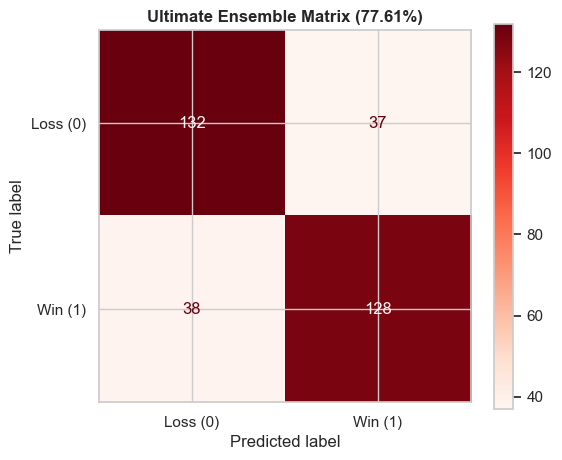

In [15]:
print("Assembling the Ultimate Optimized Voting Committee (RF + XGB + LR)...")

# =====================================================================
# PHASE 6: ENSEMBLE LEARNING (VOTING CLASSIFIER)
# =====================================================================

# 1. Instantiate the Voting Classifier
# We combine our three hyperparameter-tuned pipelines into a single ensemble model.
# Using 'soft' voting allows the ensemble to predict based on the argmax of the sums 
# of the predicted probabilities, which generally yields better results than 'hard' voting.
voting_xgb = VotingClassifier(
    estimators=[
        ('RF', best_rf_pipeline),     # Bagging: High variance reduction
        ('XGB', best_xgb_pipeline),   # Boosting: Sequential error correction
        ('LR', best_lr_pipeline)      # Linear: Baseline mathematical rationality
    ],
    voting='soft' 
)

# 2. Train the Ensemble Model
# Fitting directly on the unscaled training data (X_train).
# The RobustScaler embedded within each individual pipeline will automatically 
# handle feature scaling, strictly preventing data leakage.
voting_xgb.fit(X_train, y_train)

# 3. Execute Predictions
# Evaluating the ensemble model on the unseen test set to measure its generalization capability.
y_pred_vxgb = voting_xgb.predict(X_test)

# =====================================================================
# FINAL EVALUATION & METRICS
# =====================================================================

# Calculate overall accuracy
vxgb_acc = accuracy_score(y_test, y_pred_vxgb)

print("\n" + "="*60)
print(f"  ULTIMATE VOTING CLASSIFIER ACCURACY: {vxgb_acc:.4f} ")
print("="*60)

# Display precision, recall, and f1-score for both classes
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_vxgb))

# 4. Visualize the Confusion Matrix
# Plotting the matrix to analyze False Positives and False Negatives
cm = confusion_matrix(y_test, y_pred_vxgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Loss (0)', 'Win (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Reds', ax=ax, values_format='d')
plt.title(f'Ultimate Ensemble Matrix ({vxgb_acc:.2%})', fontweight='bold')
plt.show()

Le Modèle d'Ensemble Ultime (Soft Voting Classifier)
Pour repousser notre plafond prédictif, nous combinons nos trois meilleurs pipelines optimisés en un seul Soft Voting Classifier. 

Le Comité de Décision :
1.  Random Forest (Bagging) : L'ancre stable (Forte réduction de la variance).
2.  XGBoost (Boosting) : Le correcteur d'erreurs (Capture les modèles complexes et non-linéaires).
3.  Logistic Regression (Linéaire) : La base rationnelle (Empêche la surcomplication mathématique).

En faisant la moyenne des probabilités prédites (`voting='soft'`) de ces trois architectures distinctes, l'ensemble prend une décision finale hautement robuste et capable de se généraliser sur de nouvelles données.

In [16]:
print("Running 5-Fold Cross-Validation on the Ultimate Voting Classifier...")
print("This might take a minute as it trains 3 models x 5 times...\n")

# Run cross-validation on the scaled training data
# cv=5 means it will split the train data into 5 parts, train on 4, test on 1, and repeat 5 times.
cv_scores = cross_val_score(voting_xgb, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

# Display the results
print("="*60)
print(" CROSS-VALIDATION RESULTS (ULTIMATE VOTING CLASSIFIER) ")
print("="*60)
print(f"Accuracy across the 5 folds: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} ({np.mean(cv_scores)*100:.2f}%)")
print(f"Standard Deviation: +/- {np.std(cv_scores):.4f} (Shows stability)")
print("="*60)

Running 5-Fold Cross-Validation on the Ultimate Voting Classifier...
This might take a minute as it trains 3 models x 5 times...

 CROSS-VALIDATION RESULTS (ULTIMATE VOTING CLASSIFIER) 
Accuracy across the 5 folds: [0.80223881 0.75746269 0.71535581 0.78277154 0.79775281]
Mean CV Accuracy: 0.7711 (77.11%)
Standard Deviation: +/- 0.0320 (Shows stability)


Évaluation de la Robustesse : Validation Croisée (Cross-Validation à 5 plis)

Bien que notre modèle d'ensemble ait obtenu un excellent score sur l'ensemble de test, une évaluation rigoureuse en Machine Learning nécessite de prouver sa stabilité. 

Pour nous assurer que notre modèle ne souffre pas de surapprentissage (Overfitting) ou qu'il n'a pas simplement bénéficié d'un découpage chanceux des données, nous appliquons une **Validation Croisée à 5 plis (5-Fold Cross-Validation)** directement sur l'ensemble d'entraînement. 

Métriques clés analysées :
* Précision Moyenne (Mean Accuracy) : Confirme la performance réelle et généralisable du modèle d'ensemble.
* Écart-type (Standard Deviation) : Mesure la variance. Un écart-type faible prouve que le modèle est très stable et se comporte de manière consistante, quelles que soient les données qu'on lui présente.

In [17]:
print("Exporting the Ultimate Voting Classifier for the Web App...")

# Create models folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# Export the FINAL voting pipeline
# We don't need to export the scaler separately anymore because it's INSIDE the pipeline!
joblib.dump(voting_xgb, 'models/voting_model.pkl')

# Export the champion win rates dictionary (needed for the draft advantage calculation in app.py)
joblib.dump(train_champ_win_rates, 'models/champ_win_rates.pkl')

print(" ML Assets successfully exported! You can now run your Flask App.")

Exporting the Ultimate Voting Classifier for the Web App...
 ML Assets successfully exported! You can now run your Flask App.
